# Audio-Only vs Full Pipeline Comparison

This notebook compares the results from:
1. **Audio-Only Inference**: Using only audio classification
2. **Full Pipeline**: Using both audio and video inference

## Comparison Metrics
- Violation detection rates
- Severity distribution
- Classification accuracy
- Construction site detection impact
- Overall compliance rates

## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 2. Load Data

Load the results from both approaches:
- **Audio-only**: Results from audio inference only
- **Full pipeline**: Results from integrated audio + video inference

In [2]:
# Load audio-only results (from audio inference CSV)
audio_only_path = './output/events/audio_inference/inference_results_20251102_013925.csv'
audio_only = pd.read_csv(audio_only_path)

# Load full pipeline results (from event storage CSV)
full_pipeline_path = './output/events/csv/events_detailed_20251102_014036.csv'
full_pipeline = pd.read_csv(full_pipeline_path)

print("📊 DATA LOADED")
print("=" * 80)
print(f"Audio-only inference: {len(audio_only)} entries")
print(f"Full pipeline events: {len(full_pipeline)} events")
print("=" * 80)

# Show column comparison
print("\n📋 Available Data:")
print(f"\nAudio-only columns: {len(audio_only.columns)}")
print(f"Full pipeline columns: {len(full_pipeline.columns)}")
print("\nAudio-only sample:")
print(audio_only[['filename', 'predicted_class_name', 'confidence']].head())
print("\nFull pipeline sample:")
print(full_pipeline[['event_id', 'severity', 'is_compliant', 'violations']].head())

📊 DATA LOADED
Audio-only inference: 193 entries
Full pipeline events: 190 events

📋 Available Data:

Audio-only columns: 13
Full pipeline columns: 34

Audio-only sample:
                     filename predicted_class_name  confidence
0  test_clip_1_chunk_0000.wav    motorvehicle-horn    0.436190
1  test_clip_1_chunk_0001.wav    motorvehicle-horn    0.705155
2  test_clip_1_chunk_0002.wav    motorvehicle-horn    0.495753
3  test_clip_1_chunk_0003.wav   motorvehicle-siren    0.331391
4  test_clip_1_chunk_0004.wav            generator    0.837812

Full pipeline sample:
                 event_id   severity  is_compliant        violations
0  test_clip_1_chunk_0000  compliant          True      no_violation
1  test_clip_1_chunk_0001      minor         False  ambient_exceeded
2  test_clip_1_chunk_0002      minor         False  ambient_exceeded
3  test_clip_1_chunk_0003      minor         False  ambient_exceeded
4  test_clip_1_chunk_0004      minor         False  ambient_exceeded


## 3. Prepare Comparison Data

Align both datasets for proper comparison.

In [3]:
# Extract chunk IDs for matching
audio_only['chunk_id'] = audio_only['filename'].str.replace('.wav', '')
full_pipeline['chunk_id'] = full_pipeline['event_id']

# Create comparison summary
comparison_data = {
    'audio_only': {
        'total_chunks': len(audio_only),
        'unique_classes': audio_only['predicted_class_name'].nunique(),
        'avg_confidence': audio_only['confidence'].mean(),
        'class_distribution': audio_only['predicted_class_name'].value_counts().to_dict()
    },
    'full_pipeline': {
        'total_events': len(full_pipeline),
        'compliant': len(full_pipeline[full_pipeline['is_compliant'] == True]),
        'violations': len(full_pipeline[full_pipeline['is_compliant'] == False]),
        'severity_distribution': full_pipeline['severity'].value_counts().to_dict(),
        'avg_noise_level': full_pipeline['noise_level_db'].mean(),
        'construction_detected': len(full_pipeline[full_pipeline['is_construction_site'] == True])
    }
}

print("📊 COMPARISON SUMMARY")
print("=" * 80)
print("\n🎵 Audio-Only Inference:")
print(f"  Total chunks: {comparison_data['audio_only']['total_chunks']}")
print(f"  Unique classes detected: {comparison_data['audio_only']['unique_classes']}")
print(f"  Average confidence: {comparison_data['audio_only']['avg_confidence']:.2%}")

print("\n🎬 Full Pipeline (Audio + Video):")
print(f"  Total events: {comparison_data['full_pipeline']['total_events']}")
print(f"  Compliant: {comparison_data['full_pipeline']['compliant']} ({comparison_data['full_pipeline']['compliant']/comparison_data['full_pipeline']['total_events']*100:.1f}%)")
print(f"  Violations: {comparison_data['full_pipeline']['violations']} ({comparison_data['full_pipeline']['violations']/comparison_data['full_pipeline']['total_events']*100:.1f}%)")
print(f"  Avg noise level: {comparison_data['full_pipeline']['avg_noise_level']:.2f} dB")
print(f"  Construction sites detected: {comparison_data['full_pipeline']['construction_detected']}")
print("=" * 80)

📊 COMPARISON SUMMARY

🎵 Audio-Only Inference:
  Total chunks: 193
  Unique classes detected: 6
  Average confidence: 56.55%

🎬 Full Pipeline (Audio + Video):
  Total events: 190
  Compliant: 9 (4.7%)
  Violations: 181 (95.3%)
  Avg noise level: 64.22 dB
  Construction sites detected: 91


## 4. Visualization 1: Classification Distribution Comparison

Compare what each approach detected.

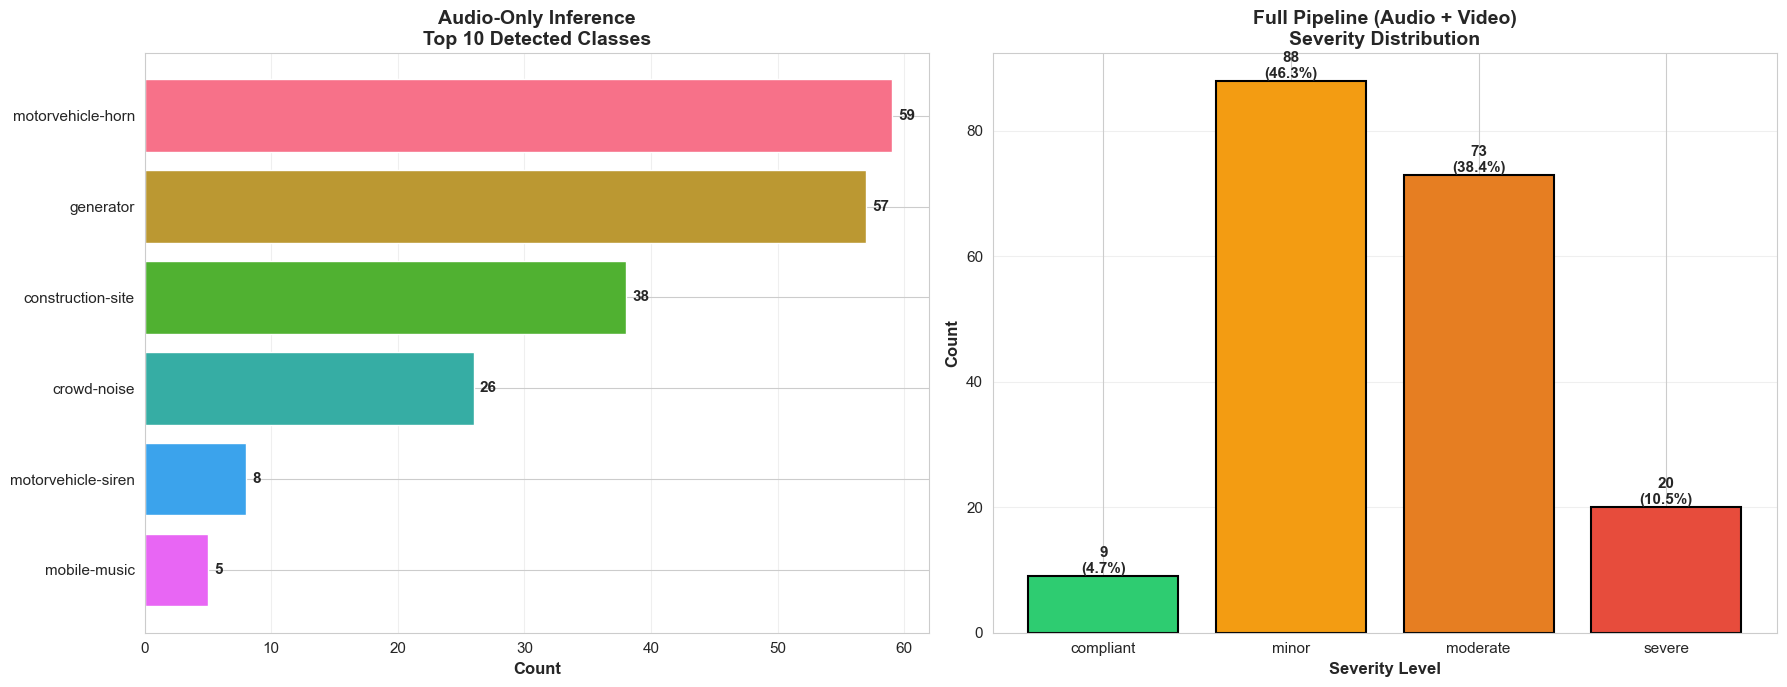

✅ Classification distribution comparison complete


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Audio-only: Top audio classes
ax1 = axes[0]
audio_classes = audio_only['predicted_class_name'].value_counts().head(10)
colors_audio = sns.color_palette("husl", len(audio_classes))
ax1.barh(range(len(audio_classes)), audio_classes.values, color=colors_audio)
ax1.set_yticks(range(len(audio_classes)))
ax1.set_yticklabels(audio_classes.index)
ax1.set_xlabel('Count', fontsize=12, fontweight='bold')
ax1.set_title('Audio-Only Inference\nTop 10 Detected Classes', fontsize=14, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# Add count labels
for i, v in enumerate(audio_classes.values):
    ax1.text(v + 0.5, i, str(v), va='center', fontweight='bold')

# Full pipeline: Severity distribution
ax2 = axes[1]
severity_counts = full_pipeline['severity'].value_counts()
severity_order = ['compliant', 'minor', 'moderate', 'severe']
severity_counts = severity_counts.reindex(severity_order, fill_value=0)
colors_severity = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
bars = ax2.bar(severity_order, severity_counts.values, color=colors_severity, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Count', fontsize=12, fontweight='bold')
ax2.set_xlabel('Severity Level', fontsize=12, fontweight='bold')
ax2.set_title('Full Pipeline (Audio + Video)\nSeverity Distribution', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add count and percentage labels
total = severity_counts.sum()
for bar, count in zip(bars, severity_counts.values):
    height = bar.get_height()
    percentage = (count / total) * 100
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{count}\n({percentage:.1f}%)',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ Classification distribution comparison complete")

## 5. Visualization 2: Compliance Rate Comparison

Compare how compliance is affected by adding video inference.

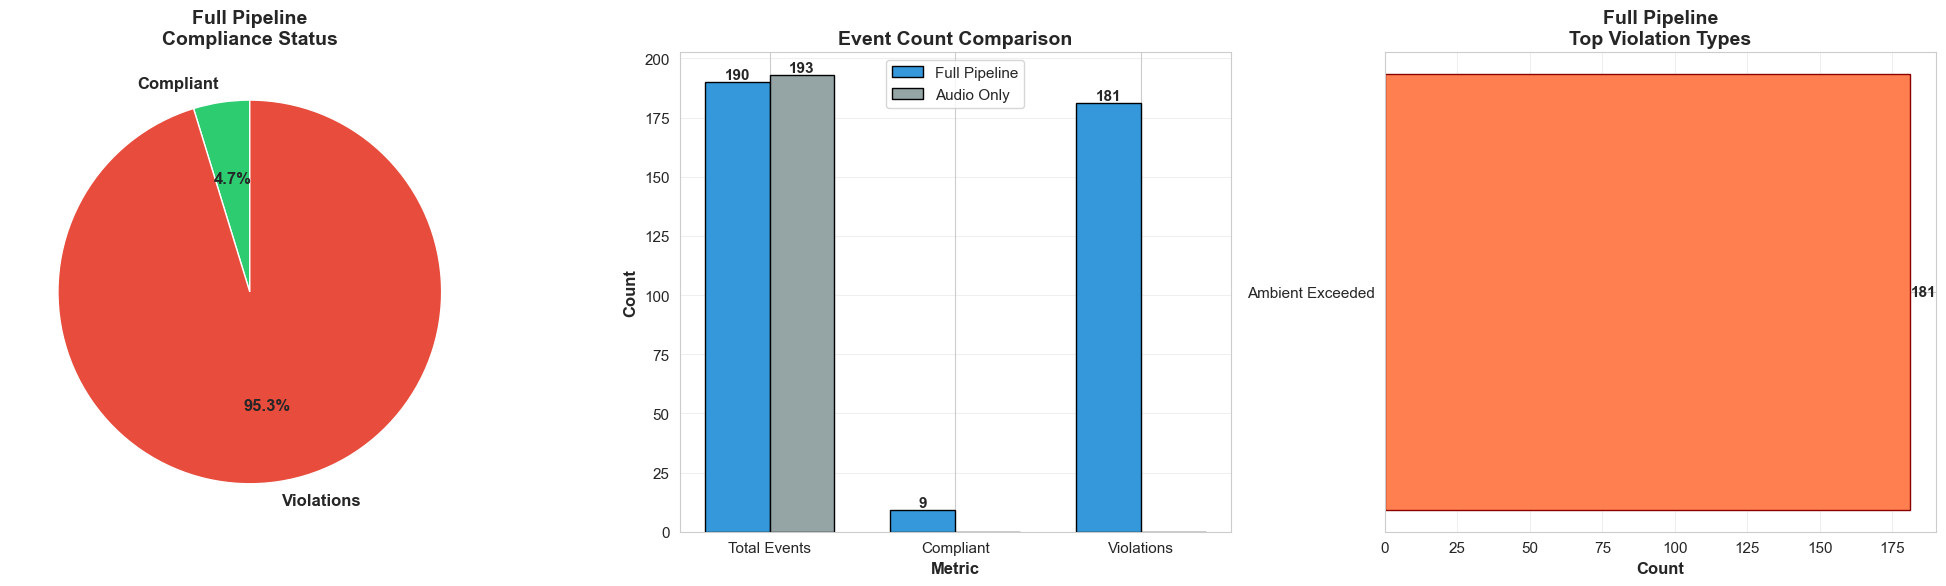

✅ Compliance comparison complete


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Compliance pie chart for full pipeline
ax1 = axes[0]
compliant = len(full_pipeline[full_pipeline['is_compliant'] == True])
violations = len(full_pipeline[full_pipeline['is_compliant'] == False])
ax1.pie([compliant, violations], 
        labels=['Compliant', 'Violations'],
        autopct='%1.1f%%',
        colors=['#2ecc71', '#e74c3c'],
        startangle=90,
        textprops={'fontsize': 12, 'fontweight': 'bold'})
ax1.set_title('Full Pipeline\nCompliance Status', fontsize=14, fontweight='bold')

# Comparison bar chart
ax2 = axes[1]
comparison = pd.DataFrame({
    'Metric': ['Total Events', 'Compliant', 'Violations'],
    'Full Pipeline': [len(full_pipeline), compliant, violations],
    'Audio Only\n(No Compliance)': [len(audio_only), 0, 0]
})

x = np.arange(len(comparison['Metric']))
width = 0.35

bars1 = ax2.bar(x - width/2, comparison['Full Pipeline'], width, 
                label='Full Pipeline', color='#3498db', edgecolor='black')
bars2 = ax2.bar(x + width/2, comparison['Audio Only\n(No Compliance)'], width,
                label='Audio Only', color='#95a5a6', edgecolor='black')

ax2.set_xlabel('Metric', fontsize=12, fontweight='bold')
ax2.set_ylabel('Count', fontsize=12, fontweight='bold')
ax2.set_title('Event Count Comparison', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(comparison['Metric'])
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                     f'{int(height)}',
                     ha='center', va='bottom', fontweight='bold')

# Violation types breakdown
ax3 = axes[2]
# Count violation occurrences
violation_counts = {}
for violations_str in full_pipeline['violations'].dropna():
    if violations_str != 'no_violation':
        # Split multiple violations
        violations = violations_str.split(',')
        for v in violations:
            v = v.strip()
            violation_counts[v] = violation_counts.get(v, 0) + 1

if violation_counts:
    top_violations = sorted(violation_counts.items(), key=lambda x: x[1], reverse=True)[:6]
    v_names = [v[0].replace('_', ' ').title() for v in top_violations]
    v_counts = [v[1] for v in top_violations]
    
    ax3.barh(range(len(v_names)), v_counts, color='coral', edgecolor='darkred')
    ax3.set_yticks(range(len(v_names)))
    ax3.set_yticklabels(v_names)
    ax3.set_xlabel('Count', fontsize=12, fontweight='bold')
    ax3.set_title('Full Pipeline\nTop Violation Types', fontsize=14, fontweight='bold')
    ax3.invert_yaxis()
    ax3.grid(axis='x', alpha=0.3)
    
    # Add count labels
    for i, v in enumerate(v_counts):
        ax3.text(v + 0.5, i, str(v), va='center', fontweight='bold')
else:
    ax3.text(0.5, 0.5, 'No violations detected', 
             ha='center', va='center', transform=ax3.transAxes, fontsize=14)

plt.tight_layout()
plt.show()

print("✅ Compliance comparison complete")

## 6. Visualization 3: Confidence and Noise Level Analysis

Compare confidence levels and noise measurements.

C:\Users\prana\AppData\Local\Temp\ipykernel_9288\98781263.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot([filtered_audio[filtered_audio['predicted_class_name'] == cls]['confidence'].values


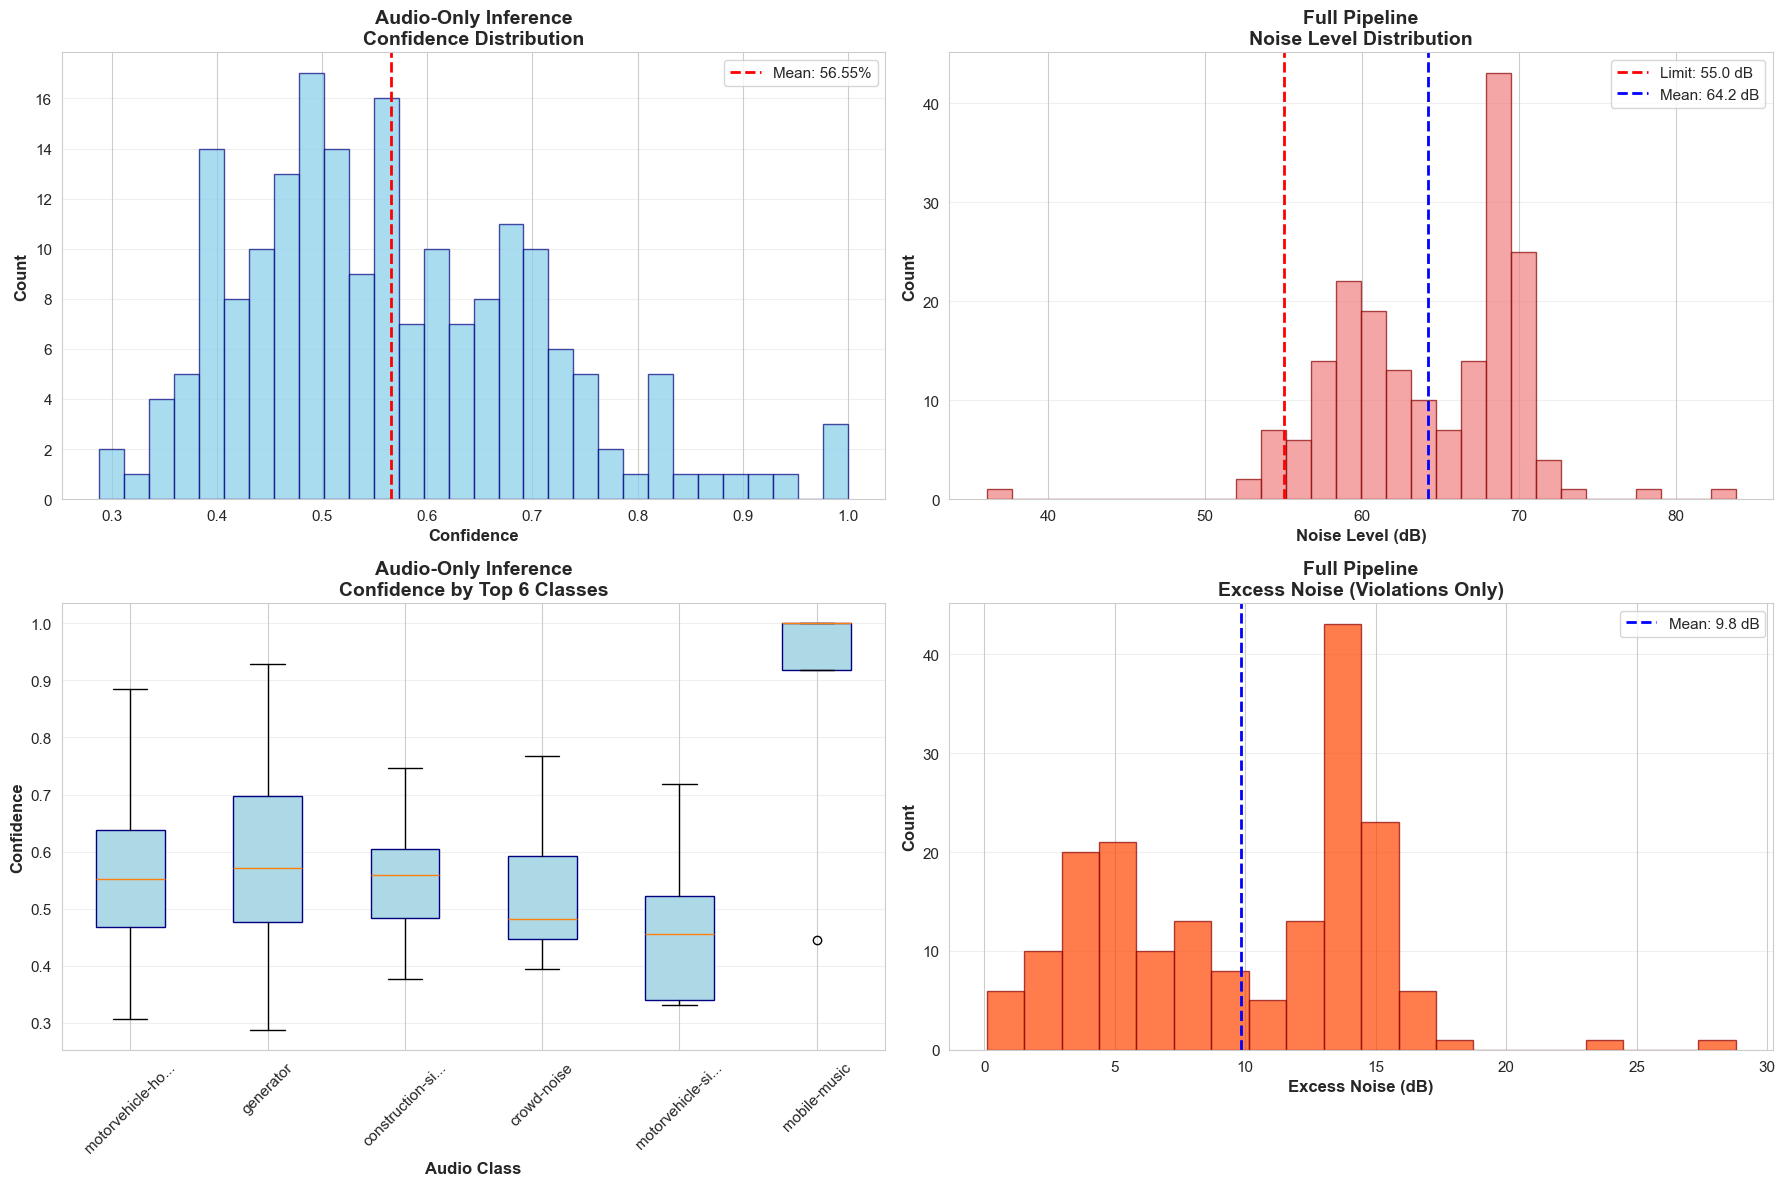

✅ Confidence and noise level analysis complete


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Audio confidence distribution
ax1 = axes[0, 0]
ax1.hist(audio_only['confidence'], bins=30, color='skyblue', edgecolor='navy', alpha=0.7)
ax1.axvline(audio_only['confidence'].mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Mean: {audio_only["confidence"].mean():.2%}')
ax1.set_xlabel('Confidence', fontsize=12, fontweight='bold')
ax1.set_ylabel('Count', fontsize=12, fontweight='bold')
ax1.set_title('Audio-Only Inference\nConfidence Distribution', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 2. Noise level distribution (full pipeline)
ax2 = axes[0, 1]
noise_levels = full_pipeline['noise_level_db'].values
ambient_limit = full_pipeline['ambient_limit_db'].iloc[0]
ax2.hist(noise_levels, bins=30, color='lightcoral', edgecolor='darkred', alpha=0.7)
ax2.axvline(ambient_limit, color='red', linestyle='--', 
            linewidth=2, label=f'Limit: {ambient_limit:.1f} dB')
ax2.axvline(noise_levels.mean(), color='blue', linestyle='--', 
            linewidth=2, label=f'Mean: {noise_levels.mean():.1f} dB')
ax2.set_xlabel('Noise Level (dB)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Count', fontsize=12, fontweight='bold')
ax2.set_title('Full Pipeline\nNoise Level Distribution', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 3. Box plot comparison of audio confidence by class
ax3 = axes[1, 0]
top_classes = audio_only['predicted_class_name'].value_counts().head(6).index
filtered_audio = audio_only[audio_only['predicted_class_name'].isin(top_classes)]
class_names_short = [name[:15] + '...' if len(name) > 15 else name for name in top_classes]
bp = ax3.boxplot([filtered_audio[filtered_audio['predicted_class_name'] == cls]['confidence'].values 
                   for cls in top_classes],
                  labels=class_names_short,
                  patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
    patch.set_edgecolor('navy')
ax3.set_ylabel('Confidence', fontsize=12, fontweight='bold')
ax3.set_xlabel('Audio Class', fontsize=12, fontweight='bold')
ax3.set_title('Audio-Only Inference\nConfidence by Top 6 Classes', fontsize=14, fontweight='bold')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(axis='y', alpha=0.3)

# 4. Excess noise for violations
ax4 = axes[1, 1]
violations_df = full_pipeline[full_pipeline['is_compliant'] == False]
if len(violations_df) > 0:
    excess_noise = violations_df['excess_db'].values
    ax4.hist(excess_noise, bins=20, color='orangered', edgecolor='darkred', alpha=0.7)
    ax4.axvline(excess_noise.mean(), color='blue', linestyle='--', 
                linewidth=2, label=f'Mean: {excess_noise.mean():.1f} dB')
    ax4.set_xlabel('Excess Noise (dB)', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Count', fontsize=12, fontweight='bold')
    ax4.set_title('Full Pipeline\nExcess Noise (Violations Only)', fontsize=14, fontweight='bold')
    ax4.legend()
    ax4.grid(axis='y', alpha=0.3)
else:
    ax4.text(0.5, 0.5, 'No violations', ha='center', va='center', 
             transform=ax4.transAxes, fontsize=14)

plt.tight_layout()
plt.show()

print("✅ Confidence and noise level analysis complete")

## 7. Visualization 4: Construction Site Detection Impact

Show how video inference helps detect construction sites.

C:\Users\prana\AppData\Local\Temp\ipykernel_9288\3714967059.py:76: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax4.boxplot([construction_noise, non_construction_noise],


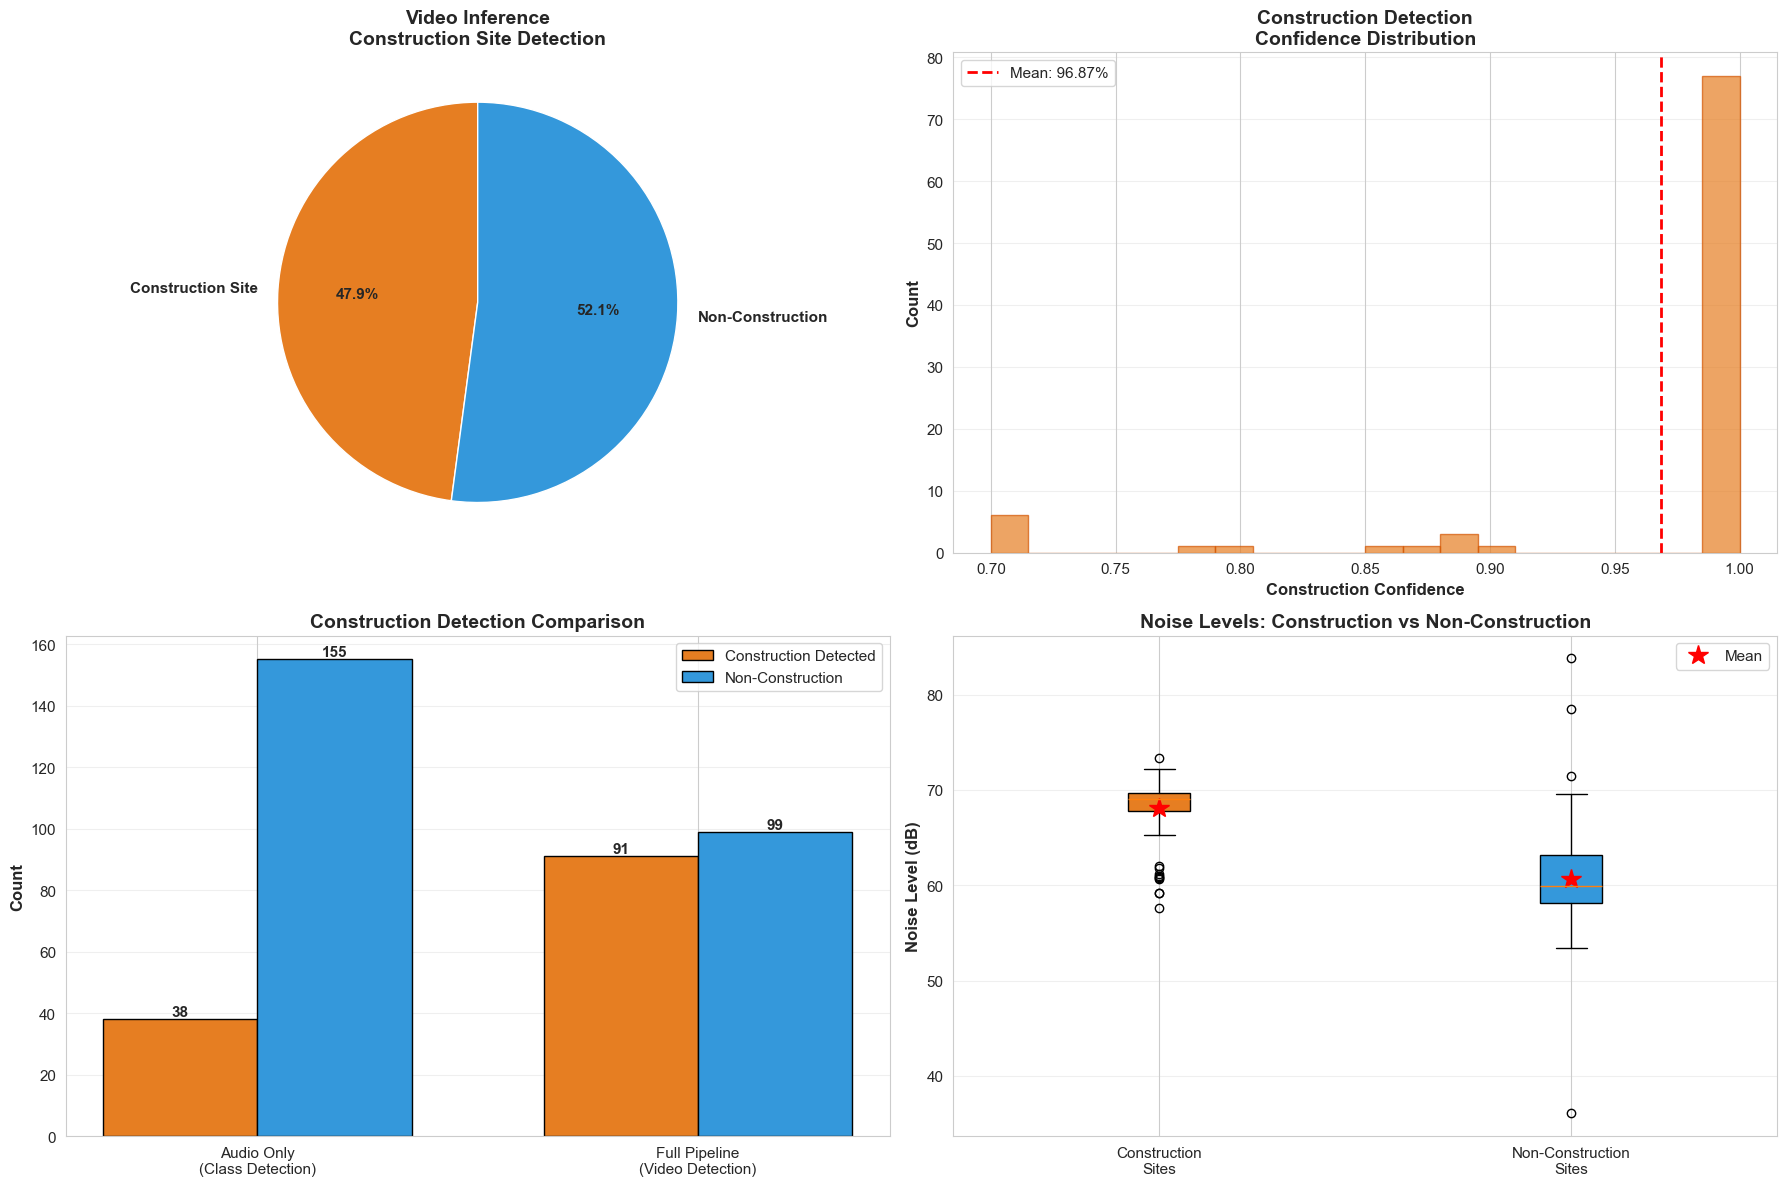

✅ Construction site analysis complete


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Construction site detection pie chart
ax1 = axes[0, 0]
construction_detected = len(full_pipeline[full_pipeline['is_construction_site'] == True])
non_construction = len(full_pipeline[full_pipeline['is_construction_site'] == False])
ax1.pie([construction_detected, non_construction],
        labels=['Construction Site', 'Non-Construction'],
        autopct='%1.1f%%',
        colors=['#e67e22', '#3498db'],
        startangle=90,
        textprops={'fontsize': 11, 'fontweight': 'bold'})
ax1.set_title('Video Inference\nConstruction Site Detection', fontsize=14, fontweight='bold')

# 2. Construction confidence distribution
ax2 = axes[0, 1]
construction_df = full_pipeline[full_pipeline['is_construction_site'] == True]
if len(construction_df) > 0:
    ax2.hist(construction_df['construction_confidence'], bins=20, 
             color='#e67e22', edgecolor='#d35400', alpha=0.7)
    ax2.axvline(construction_df['construction_confidence'].mean(), 
                color='red', linestyle='--', linewidth=2,
                label=f'Mean: {construction_df["construction_confidence"].mean():.2%}')
    ax2.set_xlabel('Construction Confidence', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Count', fontsize=12, fontweight='bold')
    ax2.set_title('Construction Detection\nConfidence Distribution', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'No construction sites detected', 
             ha='center', va='center', transform=ax2.transAxes, fontsize=14)

# 3. Audio class detection at construction sites vs non-construction
ax3 = axes[1, 0]
# Count "construction-site" audio class in audio-only data
audio_construction = len(audio_only[audio_only['predicted_class_name'] == 'construction-site'])
audio_non_construction = len(audio_only[audio_only['predicted_class_name'] != 'construction-site'])

# Video-detected construction sites
video_construction = construction_detected
video_non_construction = non_construction

x_labels = ['Audio Only\n(Class Detection)', 'Full Pipeline\n(Video Detection)']
construction_counts = [audio_construction, video_construction]
non_construction_counts = [audio_non_construction, video_non_construction]

x = np.arange(len(x_labels))
width = 0.35

bars1 = ax3.bar(x - width/2, construction_counts, width, 
                label='Construction Detected', color='#e67e22', edgecolor='black')
bars2 = ax3.bar(x + width/2, non_construction_counts, width,
                label='Non-Construction', color='#3498db', edgecolor='black')

ax3.set_ylabel('Count', fontsize=12, fontweight='bold')
ax3.set_title('Construction Detection Comparison', fontsize=14, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(x_labels)
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height)}',
                 ha='center', va='bottom', fontweight='bold')

# 4. Noise levels: Construction vs Non-Construction
ax4 = axes[1, 1]
construction_noise = full_pipeline[full_pipeline['is_construction_site'] == True]['noise_level_db'].values
non_construction_noise = full_pipeline[full_pipeline['is_construction_site'] == False]['noise_level_db'].values

if len(construction_noise) > 0 and len(non_construction_noise) > 0:
    bp = ax4.boxplot([construction_noise, non_construction_noise],
                      labels=['Construction\nSites', 'Non-Construction\nSites'],
                      patch_artist=True)
    bp['boxes'][0].set_facecolor('#e67e22')
    bp['boxes'][1].set_facecolor('#3498db')
    for box in bp['boxes']:
        box.set_edgecolor('black')
    
    ax4.set_ylabel('Noise Level (dB)', fontsize=12, fontweight='bold')
    ax4.set_title('Noise Levels: Construction vs Non-Construction', fontsize=14, fontweight='bold')
    ax4.grid(axis='y', alpha=0.3)
    
    # Add mean markers
    ax4.plot([1], [construction_noise.mean()], 'r*', markersize=15, label='Mean')
    ax4.plot([2], [non_construction_noise.mean()], 'r*', markersize=15)
    ax4.legend()
else:
    ax4.text(0.5, 0.5, 'Insufficient data for comparison', 
             ha='center', va='center', transform=ax4.transAxes, fontsize=14)

plt.tight_layout()
plt.show()

print("✅ Construction site analysis complete")

## 8. Visualization 5: Multimodal Detection Comparison

Show how audio and video detections complement each other.

C:\Users\prana\AppData\Local\Temp\ipykernel_9288\2897869854.py:118: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
d:\Projects\UrbanNoiseClassifier\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


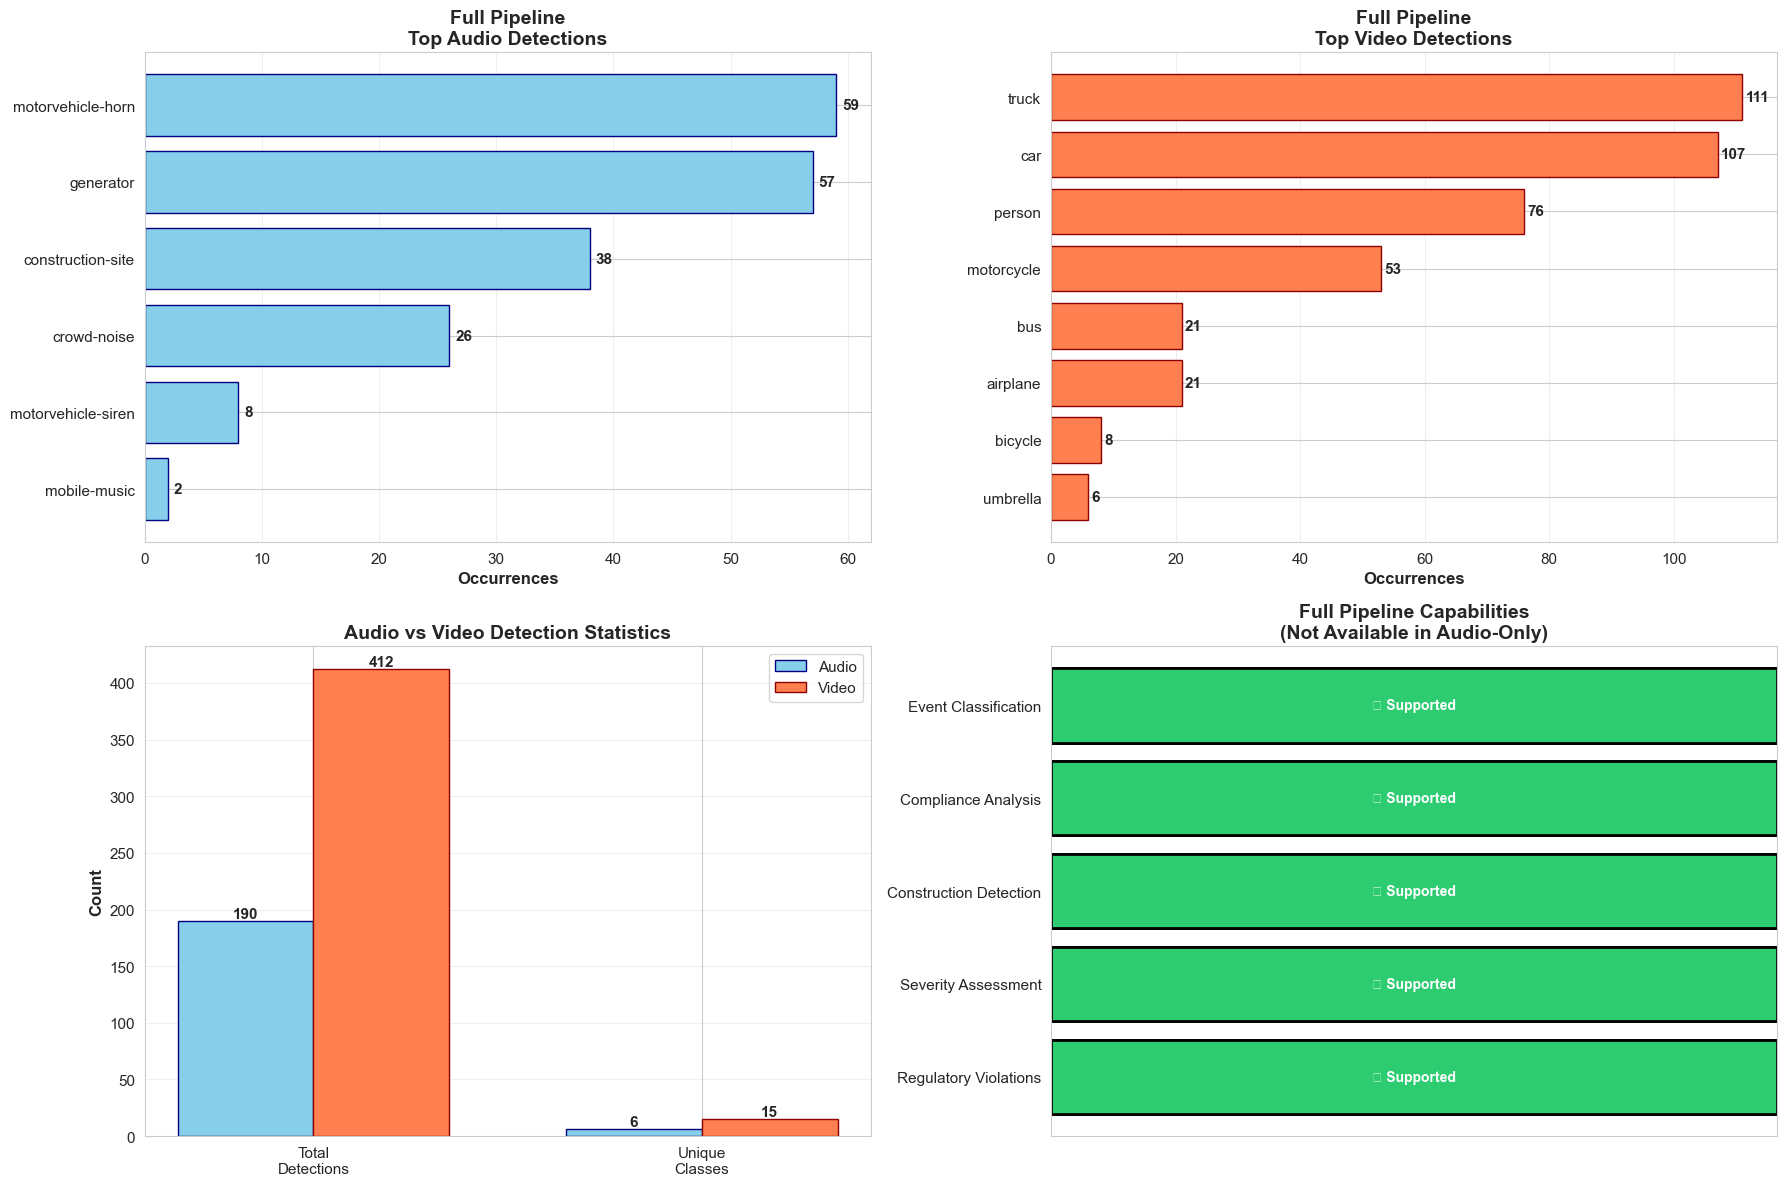

✅ Multimodal detection comparison complete


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Top audio detections in full pipeline
ax1 = axes[0, 0]
audio_cols = [col for col in full_pipeline.columns if col.startswith('audio_')]
audio_detections = {}
for col in audio_cols:
    class_name = col.replace('audio_', '')
    count = full_pipeline[col].notna().sum()
    if count > 0:
        audio_detections[class_name] = count

if audio_detections:
    top_audio = sorted(audio_detections.items(), key=lambda x: x[1], reverse=True)[:8]
    names, counts = zip(*top_audio)
    ax1.barh(range(len(names)), counts, color='skyblue', edgecolor='navy')
    ax1.set_yticks(range(len(names)))
    ax1.set_yticklabels(names)
    ax1.set_xlabel('Occurrences', fontsize=12, fontweight='bold')
    ax1.set_title('Full Pipeline\nTop Audio Detections', fontsize=14, fontweight='bold')
    ax1.invert_yaxis()
    ax1.grid(axis='x', alpha=0.3)
    
    for i, v in enumerate(counts):
        ax1.text(v + 0.5, i, str(v), va='center', fontweight='bold')

# 2. Top video detections in full pipeline
ax2 = axes[0, 1]
video_cols = [col for col in full_pipeline.columns if col.startswith('video_')]
video_detections = {}
for col in video_cols:
    class_name = col.replace('video_', '')
    count = full_pipeline[col].notna().sum()
    if count > 0:
        video_detections[class_name] = count

if video_detections:
    top_video = sorted(video_detections.items(), key=lambda x: x[1], reverse=True)[:8]
    names, counts = zip(*top_video)
    ax2.barh(range(len(names)), counts, color='coral', edgecolor='darkred')
    ax2.set_yticks(range(len(names)))
    ax2.set_yticklabels(names)
    ax2.set_xlabel('Occurrences', fontsize=12, fontweight='bold')
    ax2.set_title('Full Pipeline\nTop Video Detections', fontsize=14, fontweight='bold')
    ax2.invert_yaxis()
    ax2.grid(axis='x', alpha=0.3)
    
    for i, v in enumerate(counts):
        ax2.text(v + 0.5, i, str(v), va='center', fontweight='bold')

# 3. Detection count comparison
ax3 = axes[1, 0]
total_audio_detections = sum(audio_detections.values()) if audio_detections else 0
total_video_detections = sum(video_detections.values()) if video_detections else 0
unique_audio_classes = len(audio_detections) if audio_detections else 0
unique_video_classes = len(video_detections) if video_detections else 0

categories = ['Total\nDetections', 'Unique\nClasses']
audio_values = [total_audio_detections, unique_audio_classes]
video_values = [total_video_detections, unique_video_classes]

x = np.arange(len(categories))
width = 0.35

bars1 = ax3.bar(x - width/2, audio_values, width, 
                label='Audio', color='skyblue', edgecolor='navy')
bars2 = ax3.bar(x + width/2, video_values, width,
                label='Video', color='coral', edgecolor='darkred')

ax3.set_ylabel('Count', fontsize=12, fontweight='bold')
ax3.set_title('Audio vs Video Detection Statistics', fontsize=14, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(categories)
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height)}',
                 ha='center', va='bottom', fontweight='bold')

# 4. Value added by full pipeline
ax4 = axes[1, 1]
metrics = [
    'Event Classification',
    'Compliance Analysis',
    'Construction Detection',
    'Severity Assessment',
    'Regulatory Violations'
]
audio_only_capable = [0, 0, 0, 0, 0]  # Audio-only can't do these
full_pipeline_capable = [1, 1, 1, 1, 1]  # Full pipeline can do all

y_pos = np.arange(len(metrics))
colors_metrics = ['#95a5a6', '#3498db']

fig_sub = ax4.barh(y_pos, [1]*len(metrics), color='#ecf0f1', edgecolor='black', linewidth=2)
for i, (audio_val, full_val) in enumerate(zip(audio_only_capable, full_pipeline_capable)):
    if full_val == 1:
        ax4.barh(i, full_val, color='#2ecc71', edgecolor='black', linewidth=2)
        ax4.text(0.5, i, '✓ Supported', ha='center', va='center', 
                fontweight='bold', fontsize=10, color='white')
    else:
        ax4.text(0.5, i, '✗ Not Available', ha='center', va='center',
                fontweight='bold', fontsize=10, color='#7f8c8d')

ax4.set_yticks(y_pos)
ax4.set_yticklabels(metrics)
ax4.set_xlim(0, 1)
ax4.set_xticks([])
ax4.set_title('Full Pipeline Capabilities\n(Not Available in Audio-Only)', 
              fontsize=14, fontweight='bold')
ax4.invert_yaxis()

plt.tight_layout()
plt.show()

print("✅ Multimodal detection comparison complete")

## 9. Summary Statistics Table

Comprehensive comparison of key metrics.

In [9]:
# Create comprehensive comparison table
summary_table = pd.DataFrame({
    'Metric': [
        'Total Chunks/Events',
        'Unique Classes Detected',
        'Average Confidence',
        'Compliant Events',
        'Violation Events',
        'Compliance Rate',
        'Construction Sites Detected',
        'Average Noise Level (dB)',
        'Severe Violations',
        'Moderate Violations',
        'Minor Violations',
        'Event Classification',
        'Regulatory Compliance Analysis',
        'Multi-modal Detection'
    ],
    'Audio-Only Inference': [
        len(audio_only),
        audio_only['predicted_class_name'].nunique(),
        f"{audio_only['confidence'].mean():.2%}",
        'N/A',
        'N/A',
        'N/A',
        len(audio_only[audio_only['predicted_class_name'] == 'construction-site']),
        'N/A',
        'N/A',
        'N/A',
        'N/A',
        '✗',
        '✗',
        '✗'
    ],
    'Full Pipeline (Audio + Video)': [
        len(full_pipeline),
        f"{unique_audio_classes} audio + {unique_video_classes} video",
        'N/A (multi-modal)',
        len(full_pipeline[full_pipeline['is_compliant'] == True]),
        len(full_pipeline[full_pipeline['is_compliant'] == False]),
        f"{len(full_pipeline[full_pipeline['is_compliant'] == True])/len(full_pipeline)*100:.1f}%",
        len(full_pipeline[full_pipeline['is_construction_site'] == True]),
        f"{full_pipeline['noise_level_db'].mean():.2f}",
        len(full_pipeline[full_pipeline['severity'] == 'severe']),
        len(full_pipeline[full_pipeline['severity'] == 'moderate']),
        len(full_pipeline[full_pipeline['severity'] == 'minor']),
        '✓',
        '✓',
        '✓'
    ]
})

print("\n" + "=" * 100)
print("COMPREHENSIVE COMPARISON: AUDIO-ONLY vs FULL PIPELINE")
print("=" * 100)
print(summary_table.to_string(index=False))
print("=" * 100)

# Save to CSV
comparison_output_path = './output/events/comparison_summary.csv'
summary_table.to_csv(comparison_output_path, index=False)
print(f"\n✅ Comparison table saved to: {comparison_output_path}")


COMPREHENSIVE COMPARISON: AUDIO-ONLY vs FULL PIPELINE
                        Metric Audio-Only Inference Full Pipeline (Audio + Video)
           Total Chunks/Events                  193                           190
       Unique Classes Detected                    6            6 audio + 15 video
            Average Confidence               56.55%             N/A (multi-modal)
              Compliant Events                  N/A                             9
              Violation Events                  N/A                           181
               Compliance Rate                  N/A                          4.7%
   Construction Sites Detected                   38                            91
      Average Noise Level (dB)                  N/A                         64.22
             Severe Violations                  N/A                            20
           Moderate Violations                  N/A                            73
              Minor Violations             

## 10. Key Findings and Conclusions

In [10]:
print("=" * 100)
print("KEY FINDINGS: AUDIO-ONLY vs FULL PIPELINE COMPARISON")
print("=" * 100)

# Calculate key metrics
audio_construction_count = len(audio_only[audio_only['predicted_class_name'] == 'construction-site'])
video_construction_count = len(full_pipeline[full_pipeline['is_construction_site'] == True])
compliance_rate = len(full_pipeline[full_pipeline['is_compliant'] == True]) / len(full_pipeline) * 100
violation_rate = 100 - compliance_rate

print("\n🎯 DETECTION CAPABILITIES:")
print("-" * 100)
print(f"  • Audio-Only: Detects {audio_only['predicted_class_name'].nunique()} different audio classes")
print(f"  • Full Pipeline: Combines {unique_audio_classes} audio classes + {unique_video_classes} video classes")
print(f"  • Value Added: Video inference adds {unique_video_classes} additional detection dimensions")

print("\n🏗️ CONSTRUCTION SITE DETECTION:")
print("-" * 100)
print(f"  • Audio-Only: Identified {audio_construction_count} chunks with 'construction-site' audio class")
print(f"  • Full Pipeline: Detected {video_construction_count} construction sites using video analysis")
if video_construction_count > audio_construction_count:
    improvement = ((video_construction_count - audio_construction_count) / audio_construction_count * 100) if audio_construction_count > 0 else float('inf')
    print(f"  • Improvement: {improvement:.1f}% more construction sites detected with video")
else:
    print(f"  • Note: Video provides visual confirmation beyond audio classification")

print("\n📊 COMPLIANCE ANALYSIS (Full Pipeline Only):")
print("-" * 100)
print(f"  • Compliance Rate: {compliance_rate:.1f}%")
print(f"  • Violation Rate: {violation_rate:.1f}%")
print(f"  • Severity Breakdown:")
for severity in ['compliant', 'minor', 'moderate', 'severe']:
    count = len(full_pipeline[full_pipeline['severity'] == severity])
    pct = count / len(full_pipeline) * 100
    print(f"    - {severity.capitalize()}: {count} ({pct:.1f}%)")

print("\n⚠️ VIOLATION DETECTION (Full Pipeline Only):")
print("-" * 100)
violation_counts = {}
for violations_str in full_pipeline['violations'].dropna():
    if violations_str != 'no_violation':
        violations = violations_str.split(',')
        for v in violations:
            v = v.strip()
            violation_counts[v] = violation_counts.get(v, 0) + 1

if violation_counts:
    for v_type, count in sorted(violation_counts.items(), key=lambda x: x[1], reverse=True)[:5]:
        print(f"  • {v_type.replace('_', ' ').title()}: {count} occurrences")
else:
    print("  • No violations detected")

print("\n🔬 NOISE ANALYSIS (Full Pipeline Only):")
print("-" * 100)
print(f"  • Average Noise Level: {full_pipeline['noise_level_db'].mean():.2f} dB")
print(f"  • Maximum Noise Level: {full_pipeline['noise_level_db'].max():.2f} dB")
print(f"  • Ambient Limit: {full_pipeline['ambient_limit_db'].iloc[0]:.2f} dB")
violations_df = full_pipeline[full_pipeline['is_compliant'] == False]
if len(violations_df) > 0:
    print(f"  • Average Excess (Violations): {violations_df['excess_db'].mean():.2f} dB")
    print(f"  • Maximum Excess: {violations_df['excess_db'].max():.2f} dB")

print("\n✅ ADVANTAGES OF FULL PIPELINE:")
print("-" * 100)
print("  ✓ Event Classification: Comprehensive event-level analysis")
print("  ✓ Regulatory Compliance: Automated violation detection per Indian Noise Pollution Rules")
print("  ✓ Multi-modal Detection: Combines audio and visual information")
print("  ✓ Construction Detection: Visual confirmation of construction sites")
print("  ✓ Severity Assessment: Categorizes violations by severity level")
print("  ✓ Contextual Analysis: Noise levels + audio + video for complete picture")

print("\n❌ LIMITATIONS OF AUDIO-ONLY:")
print("-" * 100)
print("  ✗ No event-level classification")
print("  ✗ No compliance analysis against regulations")
print("  ✗ No visual context (misses non-audio violations)")
print("  ✗ No construction site visual confirmation")
print("  ✗ No severity assessment")
print("  ✗ Cannot detect silent violations (e.g., construction during prohibited hours)")

print("\n💡 RECOMMENDATION:")
print("-" * 100)
print("  The Full Pipeline provides significantly more value by:")
print("  1. Adding regulatory compliance analysis")
print("  2. Combining multiple data sources (audio + video + noise levels)")
print("  3. Providing actionable severity classifications")
print("  4. Enabling comprehensive violation detection")
print("  5. Supporting evidence-based enforcement")

print("\n" + "=" * 100)
print("CONCLUSION: Full Pipeline is essential for regulatory compliance monitoring.")
print("=" * 100)

KEY FINDINGS: AUDIO-ONLY vs FULL PIPELINE COMPARISON

🎯 DETECTION CAPABILITIES:
----------------------------------------------------------------------------------------------------
  • Audio-Only: Detects 6 different audio classes
  • Full Pipeline: Combines 6 audio classes + 15 video classes
  • Value Added: Video inference adds 15 additional detection dimensions

🏗️ CONSTRUCTION SITE DETECTION:
----------------------------------------------------------------------------------------------------
  • Audio-Only: Identified 38 chunks with 'construction-site' audio class
  • Full Pipeline: Detected 91 construction sites using video analysis
  • Improvement: 139.5% more construction sites detected with video

📊 COMPLIANCE ANALYSIS (Full Pipeline Only):
----------------------------------------------------------------------------------------------------
  • Compliance Rate: 4.7%
  • Violation Rate: 95.3%
  • Severity Breakdown:
    - Compliant: 9 (4.7%)
    - Minor: 88 (46.3%)
    - Moderate

## Summary

This notebook provides a complete comparison between:

### 🎵 Audio-Only Inference
- **What it provides**: Audio classification with confidence scores
- **Limitations**: No compliance analysis, no visual context, no severity assessment
- **Use case**: Basic audio event detection

### 🎬 Full Pipeline (Audio + Video + Noise Analysis)
- **What it provides**: 
  - Complete event classification
  - Regulatory compliance analysis (Indian Noise Pollution Rules)
  - Multi-modal detection (audio + video)
  - Construction site visual detection
  - Severity-based violation categorization
  - Noise level measurements
- **Advantages**: Comprehensive, actionable, evidence-based monitoring
- **Use case**: Regulatory compliance and enforcement

### 📊 Key Visualizations Created:
1. ✅ Classification distribution comparison
2. ✅ Compliance rate analysis
3. ✅ Confidence and noise level distributions
4. ✅ Construction site detection impact
5. ✅ Multimodal detection comparison
6. ✅ Comprehensive statistics table

**Recommendation**: Use the Full Pipeline for any regulatory compliance or enforcement applications.